# Lift-Splat-Shoot lifting, step by step 🧭
### *Lift* every pixel along its ray with a depth distribution, then *splat* the 3D points into voxels

**Lifter name:** `lift_splat` · **class:** `LiftSplatLifter` · **paper:** *Lift, Splat, Shoot* (Philion & Fidler, ECCV 2020)

Same ingredients as Depth-Warp (depth distribution + context), but the direction is reversed:

| | Depth-Warp (pull) | **Lift-Splat (push)** |
|---|---|---|
| loop over | voxels | pixels × depth bins (the **frustum**) |
| step | each voxel reads the frustum | each frustum point is **unprojected to 3D** and **added** into the voxel it lands in |
| side effect | no holes | far from the camera, frustum points are sparser than voxels ⇒ **holes** |

| Step | Question |
|---|---|
| 0 | Setup and data |
| 1 | **Lift**: a 3D point for every (pixel, depth bin) |
| 2 | Which voxel does each point fall into? |
| 3 | **Splat**: `voxel_pooling` (sum / mean) with a toy example |
| 4 | Holes: why do far voxels get less? |
| 5 | The `splat` method verified against a slow loop |
| 6 | Visual: splatting with a perfect depth |
| 7 | Train and test |
| 8 | Exercises |

## Step 0: Setup and the data

> New to this repo? The notebook `tpv_lifting_step_by_step.ipynb` explains `GridSpec`, `Cameras` and the synthetic
> data in more detail. Here is the short version.

* **Ego frame:** `x` forward, `y` left, `z up` (metres). A `GridSpec` chops a box of the world into cells.
* **Cameras:** `cameras.project(points)` maps 3D ego points to pixels `(u, v)` and a depth `d`
  (*easy direction*). Going back from a pixel needs the depth (*hard direction*).
* **Data:** procedurally rendered street scenes with 4 cameras, red *vehicles* and blue *pedestrians*.
  The task is **BEV semantic segmentation**: predict the top-down class map (`0` empty, `1` vehicle, `2` pedestrian)
  from the 4 images alone. The whole camera rig is randomly rotated in every scene, so the network *has to use the calibration*.

In [1]:
import math, time, dataclasses
import numpy as np
import torch, torch.nn.functional as F
import matplotlib.pyplot as plt

from lifting import GridSpec, Cameras, build_bev_model
from lifting.data import SceneBatch, SyntheticSceneDataset
from lifting.geometry import DepthBins
from lifting.training import BEVSegmentationTask, Trainer

torch.manual_seed(0)
plt.rcParams.update({"figure.dpi": 110, "image.interpolation": "nearest"})
print("torch", torch.__version__)
from lifting.lifters import LiftSplatLifter
from lifting.ops import voxel_pooling
from lifting.encoders import SimpleConvEncoder

torch 2.14.1


images: (4, 4, 3, 48, 96) = (B, N cameras, 3, H, W)
BEV labels: (4, 32, 32) = (B, X, Y)


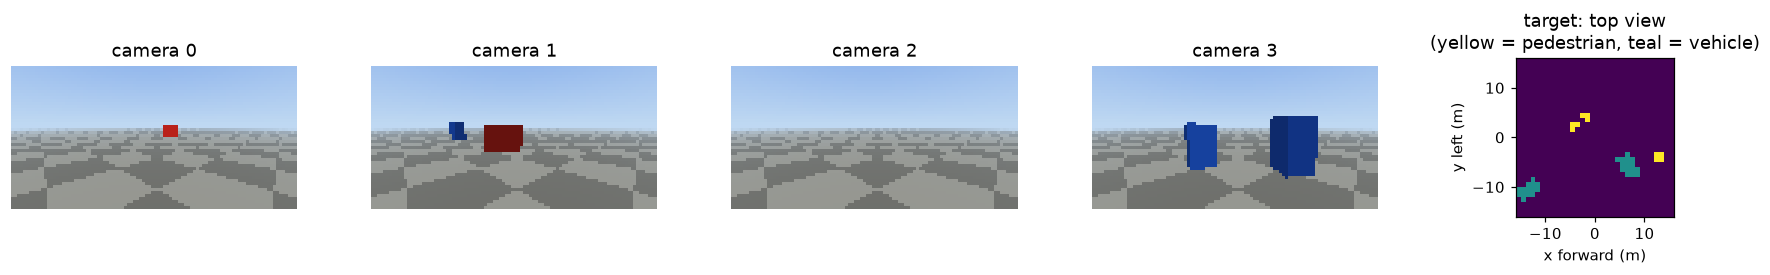

In [2]:
grid = GridSpec(resolution=(32, 32, 4))          # 32 x 32 x 4 cells of 1 m^3 over a 32 m x 32 m x 4 m box
data = SyntheticSceneDataset(256, grid, seed=1)
batch = SceneBatch.collate([data[i] for i in range(4)])
cams = batch.cameras
ext = [grid.x_bounds[0], grid.x_bounds[1], grid.y_bounds[0], grid.y_bounds[1]]
print("images:", tuple(batch.images.shape), "= (B, N cameras, 3, H, W)")
print("BEV labels:", tuple(batch.bev_labels.shape), "= (B, X, Y)")

fig, ax = plt.subplots(1, 5, figsize=(16, 2.6))
for n in range(4):
    ax[n].imshow(batch.images[0, n].permute(1, 2, 0)); ax[n].set_title(f"camera {n}"); ax[n].axis("off")
ax[4].imshow(batch.bev_labels[0].T, origin="lower", vmin=0, vmax=2, extent=ext)
ax[4].set_title("target: top view\n(yellow = pedestrian, teal = vehicle)"); ax[4].set_xlabel("x forward (m)"); ax[4].set_ylabel("y left (m)")
plt.tight_layout(); plt.show()

In [3]:
import os, sys
for _p in (".", "notebooks", os.path.join("..", "notebooks")):          # find lifting_diagrams.py next to the notebooks
    if os.path.exists(os.path.join(_p, "lifting_diagrams.py")):
        sys.path.insert(0, _p); break
import lifting_diagrams as dg

### 🖼️ Diagram: pull (Depth-Warp / Simple-BEV) vs push (Lift-Splat)
Remember the left side from the previous notebooks. This notebook is the **right** side: nothing is known about depth, so every pixel is lifted to a whole row of candidate 3D points.

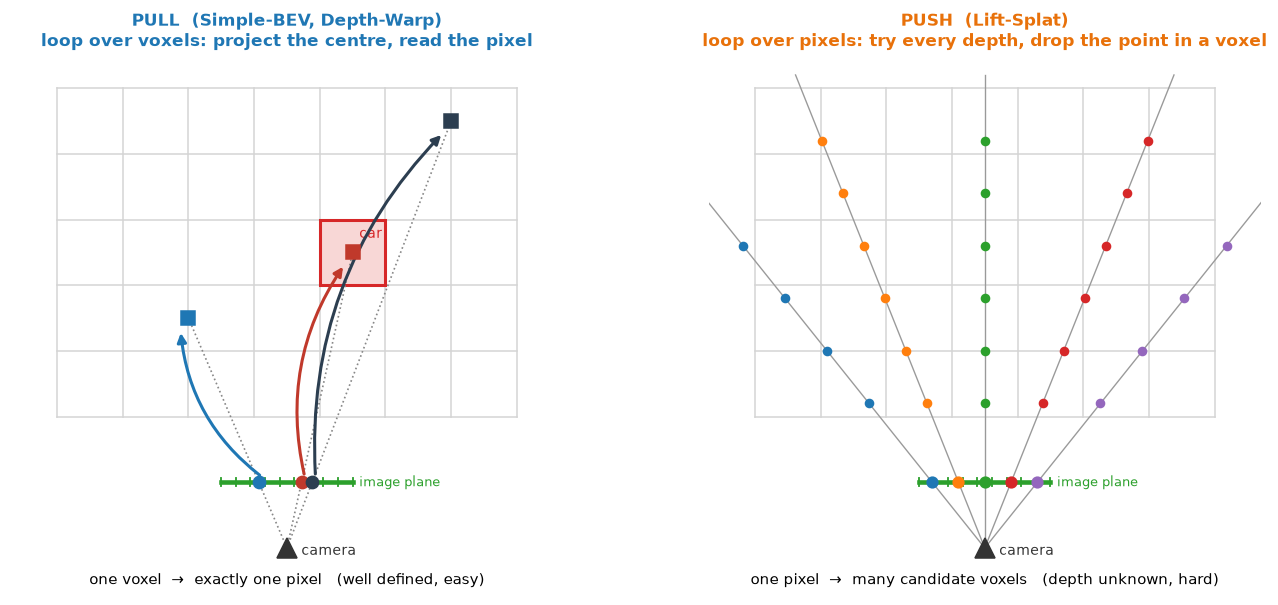

In [4]:
dg.fig_pull_vs_push()

### 🖼️ Diagram: the whole Lift-Splat lifter

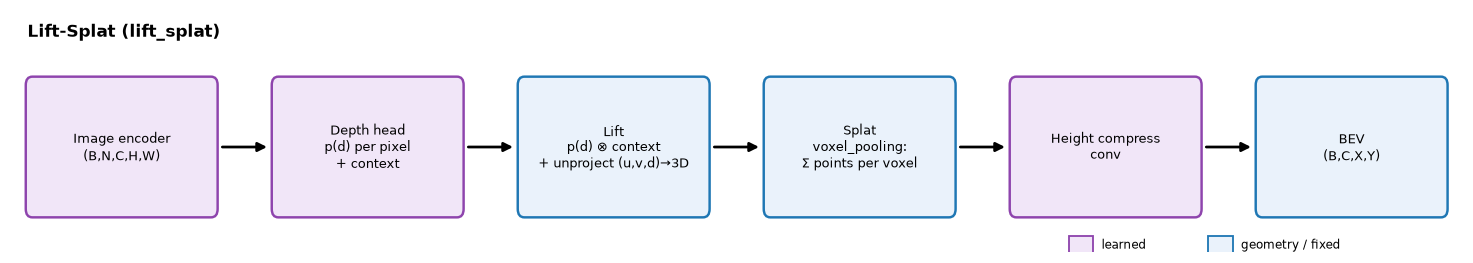

In [5]:
dg.pipeline([('Image encoder', '(B,N,C,H,W)'), ('Depth head', 'p(d) per pixel\n+ context'), ('Lift', 'p(d) ⊗ context\n+ unproject (u,v,d)→3D'), ('Splat', 'voxel_pooling:\nΣ points per voxel'), ('Height compress', 'conv'), ('BEV', '(B,C,X,Y)')], 'Lift-Splat (lift_splat)', learned=(0, 1, 4))

## Step 1: Lift: every (pixel, depth) becomes a 3D point

For a feature map of size `H×W` and `D` depth bins, the **frustum** has `D·H·W` points per camera. Each is computed by `cameras.unproject(pixel, depth)`:
the viewing ray of the pixel scaled to that depth, then moved to the ego frame. (This is the *"hard direction"* that needs a depth. Here we
simply try **all** depths.)

We also **scale the cameras to the feature-map size** (`cameras.scaled_to(h, w)`), since the lifter works on the small feature map, not the 48×96 image.

In [6]:
enc = SimpleConvEncoder(out_channels=32, num_levels=2)
with torch.no_grad():
    feats = [f.view(4, 4, *f.shape[1:]) for f in enc(batch.images.flatten(0, 1))]
h, w = feats[0].shape[-2:]
cams_f = cams.scaled_to(h, w)

ls = LiftSplatLifter(grid, in_channels=32, out_channels=32)
D = ls.depth_bins.num_bins
pts = ls.frustum_points(cams_f, h, w)
print(f"feature map {h}x{w}, {D} depth bins ->", tuple(pts.shape), "= (B, N, D*H*W, 3) ego-frame points")
print(f"{pts.shape[2]:,} frustum points per camera vs {grid.resolution[0]*grid.resolution[1]*grid.resolution[2]:,} voxels in the whole grid")

feature map 12x24, 24 depth bins -> (4, 4, 6912, 3) = (B, N, D*H*W, 3) ego-frame points
6,912 frustum points per camera vs 4,096 voxels in the whole grid


Here are the frustum points of the 4 cameras, seen from above (every 3rd point; the box is our voxel grid). Notice how the points are **dense near the camera
and spread out far away**: pixels fan out like the beams of a flashlight.

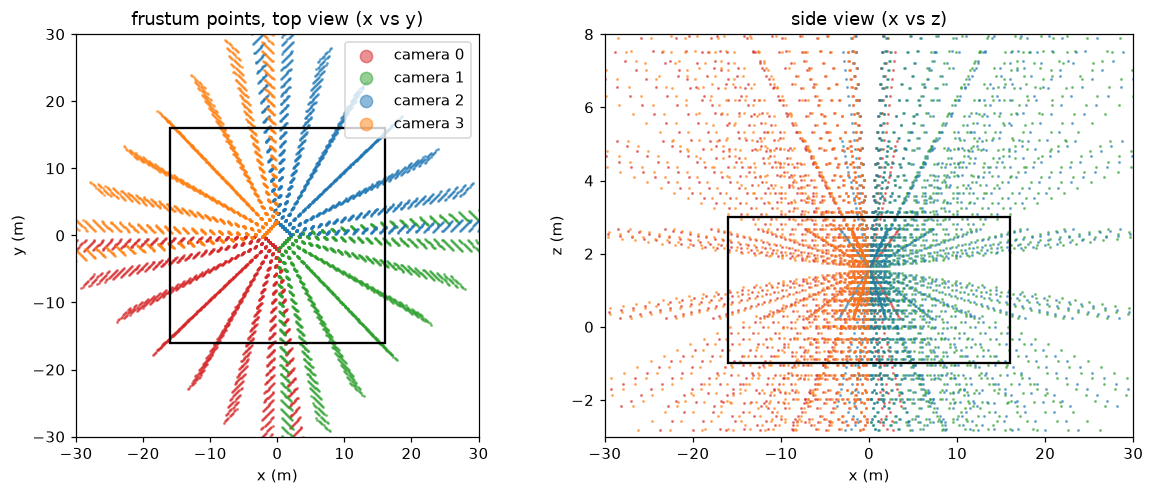

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.6))
cols = ["tab:red", "tab:green", "tab:blue", "tab:orange"]
for n in range(4):
    p = pts[0, n, ::3]
    ax[0].scatter(p[:, 0], p[:, 1], s=1, c=cols[n], alpha=0.5, label=f"camera {n}")
    ax[1].scatter(p[:, 0], p[:, 2], s=1, c=cols[n], alpha=0.5)
for a, (lo, hi) in zip(ax, ((grid.y_bounds), (grid.z_bounds))):
    a.add_patch(plt.Rectangle((grid.x_bounds[0], lo), 32, hi - lo, fill=False, ec="k", lw=1.5))
ax[0].set_xlim(-30, 30); ax[0].set_ylim(-30, 30); ax[0].set_aspect("equal"); ax[0].set_title("frustum points, top view (x vs y)"); ax[0].legend(markerscale=8)
ax[1].set_xlim(-30, 30); ax[1].set_ylim(-3, 8); ax[1].set_title("side view (x vs z)")
for a in ax: a.set_xlabel("x (m)")
ax[0].set_ylabel("y (m)"); ax[1].set_ylabel("z (m)")
plt.tight_layout(); plt.show()

## Step 2: Which voxel does each point fall into?

`grid.flat_voxel_index(points)` converts a metric point into a single integer `(x·Y + y)·Z + z` and a boolean `valid` (inside the grid).
Points outside the box are simply dropped.

In [8]:
p = torch.tensor([[[-15.9, -15.9, -0.9],      # first voxel -> index 0
                   [ 0.1,   0.1,  0.1],       # near the centre
                   [15.9,  15.9,  2.9],       # last voxel
                   [40.0,   0.0,  0.0]]])     # outside the grid
idx, ok = grid.flat_voxel_index(p)
print("flat index :", idx[0].tolist(), "  (the grid has", math.prod(grid.resolution), "voxels)")
print("inside grid:", ok[0].tolist())

flat index : [0, 2113, 4095, 4095]   (the grid has 4096 voxels)
inside grid: [True, True, True, False]


## Step 3: Splat: `voxel_pooling`

Many points can land in the same voxel; their features are **summed** (Lift-Splat) or averaged. In PyTorch this is `Tensor.index_add_`, which is
differentiable. (The original used a hand-written CUDA-like `QuickCumsum`.) Toy example: 5 points, 4 cells, 1 invalid point:

In [9]:
feat  = torch.tensor([[[1.], [2.], [4.], [8.], [16.]]])          # (B=1, P=5, C=1)
cell  = torch.tensor([[0, 2, 2, 1, 3]])
valid = torch.tensor([[True, True, True, True, False]])           # the last point is outside the grid -> dropped
print("sum :", voxel_pooling(feat, cell, valid, num_cells=4, reduce="sum").flatten().tolist(), " (cell 2 = 2 + 4)")
print("mean:", voxel_pooling(feat, cell, valid, num_cells=4, reduce="mean").flatten().tolist(), " (cell 2 = (2 + 4)/2)")

# gradients flow back to the points' features
f = feat.clone().requires_grad_(True)
voxel_pooling(f, cell, valid, 4).pow(2).sum().backward()
print("gradient wrt point features:", f.grad.flatten().tolist(), " (= 2 * pooled value; the dropped point gets 0)")

sum : [1.0, 8.0, 6.0, 0.0]  (cell 2 = 2 + 4)
mean: [1.0, 8.0, 3.0, 0.0]  (cell 2 = (2 + 4)/2)
gradient wrt point features: [2.0, 12.0, 12.0, 16.0, 0.0]  (= 2 * pooled value; the dropped point gets 0)


## Step 4: Holes: why is the splatted map patchy?

Count how many frustum points land in each voxel. Close to the cameras one voxel receives many points; far away the frustum rays diverge and
**some voxels receive none** (`count = 0` ⇒ feature 0, a *hole*). Pull methods such as Depth-Warp never have this problem.

### 🖼️ Diagram: lift, splat, and holes
Left: the lifted points (one per pixel and depth bin). Right: the number of points that land in each voxel. Near the camera many points share a voxel;
far away the rays diverge, so many voxels receive **no** point (pink holes).

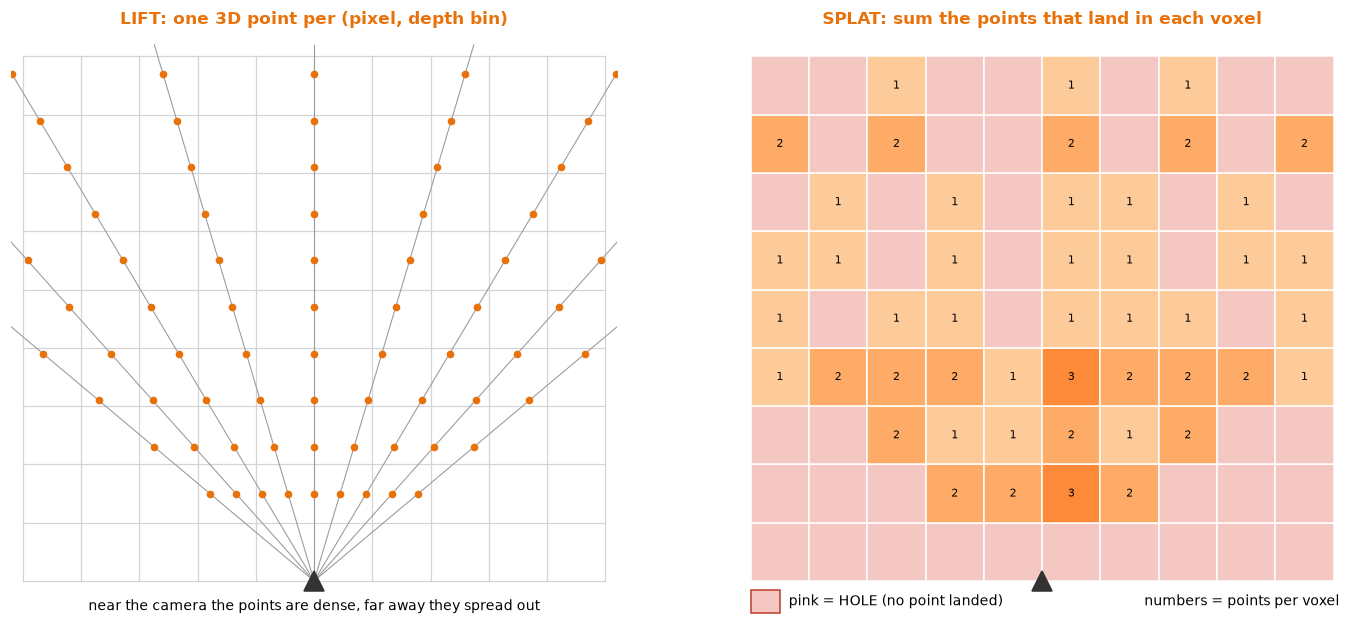

In [10]:
dg.fig_splat_holes()

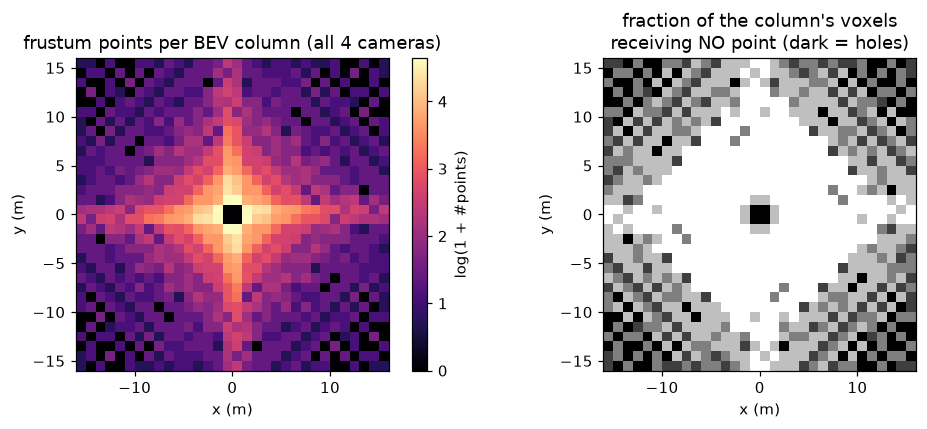

30.9% of voxels receive no frustum point at all


In [11]:
index, valid = grid.flat_voxel_index(pts.reshape(4, -1, 3))
ones = torch.ones(4, index.shape[1], 1)
count = voxel_pooling(ones, index, valid, math.prod(grid.resolution)).view(4, *grid.resolution)    # (B, X, Y, Z)
cnt_bev = count[0].sum(-1)                                                                          # points per (x, y) column

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
im = ax[0].imshow(cnt_bev.T.log1p(), origin="lower", extent=ext, cmap="magma"); plt.colorbar(im, ax=ax[0], fraction=0.046, label="log(1 + #points)")
ax[0].set_title("frustum points per BEV column (all 4 cameras)")
ax[1].imshow((count[0] == 0).float().mean(-1).T, origin="lower", extent=ext, cmap="gray_r", vmin=0, vmax=1)
ax[1].set_title("fraction of the column's voxels\nreceiving NO point (dark = holes)")
for a in ax: a.set_xlabel("x (m)"); a.set_ylabel("y (m)")
plt.tight_layout(); plt.show()
print(f"{100 * (count == 0).float().mean():.1f}% of voxels receive no frustum point at all")

In practice this is softened by (a) the **decoder** (a conv U-Net smooths holes), (b) using a **finer feature map** (more pixels), and (c) bigger voxels.

## Step 5: Verify `splat` against a slow, obvious loop

`splat(depth, context, cameras)` should equal "for every frustum point, add `depth · context` to its voxel". We check it against a plain Python loop on a small random example.

In [12]:
torch.manual_seed(1)
small = LiftSplatLifter(grid, in_channels=4, out_channels=4)
Dn = small.depth_bins.num_bins
B, N, C = 1, 4, 4
depth_p = torch.rand(B, N, Dn, h, w).softmax(2)
context = torch.randn(B, N, C, h, w)
cam_b = Cameras(cams_f.intrinsics[:1], cams_f.cam_to_ego[:1], cams_f.image_size)

with torch.no_grad():
    fast = small.splat(depth_p, context, cam_b)                        # (B, C, X, Y, Z)

# --- slow loop ---
points = small.frustum_points(cam_b, h, w)[0]                           # (N, D*H*W, 3)
idx, ok = grid.flat_voxel_index(points)
slow = torch.zeros(math.prod(grid.resolution), C)
for n in range(N):
    lifted = (depth_p[0, n][:, None] * context[0, n][None]).permute(0, 2, 3, 1).reshape(-1, C)   # (D*H*W, C)
    for i in range(lifted.shape[0]):
        if ok[n, i]:
            slow[idx[n, i]] += lifted[i]
slow = slow.view(*grid.resolution, C).permute(3, 0, 1, 2)
print("max |fast - slow| =", (fast[0] - slow).abs().max().item())
assert torch.allclose(fast[0], slow, atol=1e-4)
print("✓ vectorised splat == explicit loop")

max |fast - slow| = 0.0
✓ vectorised splat == explicit loop


## Step 6: Splatting with a perfect depth

As in the Depth-Warp notebook we cheat: one-hot GT depth, the red-pixel mask as context. Now we **push** it into the voxels.

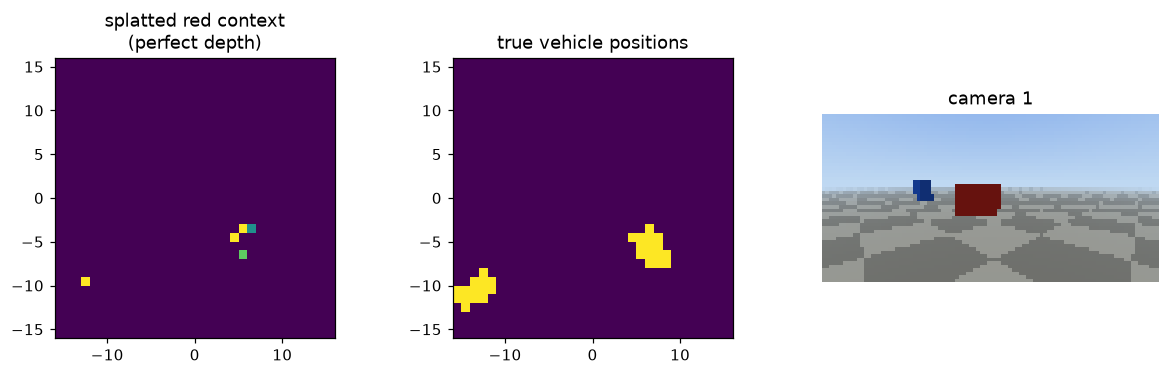

In [13]:
bins = ls.depth_bins
img = batch.images
red = ((img[:, :, 0] - torch.maximum(img[:, :, 1], img[:, :, 2])) > 0.25).float()[:, :, None]          # (B, N, 1, 48, 96)
red_f = F.adaptive_avg_pool2d(red.flatten(0, 1), (h, w)).view(4, 4, 1, h, w)                              # context at feature size
depth_f = batch.depth[:, :, 2::4, 2::4]                                                                   # (B, N, 12, 24) GT depth at feature res
idx_d = ((depth_f - bins.min_depth) / bins.step).floor().clamp(0, D - 1).long()
onehot = F.one_hot(idx_d, D).permute(0, 1, 4, 2, 3).float()                                               # (B, N, D, h, w)

s = 0
with torch.no_grad():
    vox = ls.splat(onehot, red_f, cams_f)[s, 0]                  # (X, Y, Z)
fig, ax = plt.subplots(1, 3, figsize=(11, 3.4))
ax[0].imshow(vox.amax(-1).T, origin="lower", extent=ext); ax[0].set_title("splatted red context\n(perfect depth)")
ax[1].imshow((batch.bev_labels[s] == 1).T, origin="lower", extent=ext); ax[1].set_title("true vehicle positions")
ax[2].imshow(batch.images[s, 1].permute(1, 2, 0)); ax[2].set_title("camera 1"); ax[2].axis("off")
plt.tight_layout(); plt.show()

The red context lands in the voxels at the surface where the vehicle really is (compare with Simple-BEV's long streak). The lifted features are
in the *right place*; the model must learn the depth to do the same without cheating.

## Final step: plug it into a full model, train, and test it

`build_bev_model("lift_splat", ...)` = **image encoder → `lift_splat` lifter → BEV decoder (small U-Net) → segmentation head**.
Only the lifter changes between methods. Loss is weighted cross-entropy on the BEV map; the metric is the mean IoU of the two foreground classes.
Training uses 192 scenes and the score is measured on 64 **unseen** scenes.

In [14]:
torch.manual_seed(0)
def make_batches(lo, hi, bs=4):
    return [SceneBatch.collate([data[i + j] for j in range(bs)]) for i in range(lo, hi, bs)]
train_batches, test_batches = make_batches(0, 192), make_batches(192, 256)

model = build_bev_model("lift_splat", grid, num_classes=3, image_size=(48, 96), num_cameras=4, channels=32)
n_total = sum(p.numel() for p in model.parameters()); n_lift = sum(p.numel() for p in model.lifter.parameters())
print(f"parameters: {n_total:,} total, {n_lift:,} in the lifter")

trainer = Trainer(model, BEVSegmentationTask(num_classes=3))
print("mIoU before training:", round(trainer.evaluate(test_batches).mean_foreground(), 3))
t0 = time.time()
trainer.fit(train_batches, steps=250)
print(f"trained 250 steps in {time.time() - t0:.0f}s")
print("mIoU after training :", round(trainer.evaluate(test_batches).mean_foreground(), 3))

parameters: 668,315 total, 49,112 in the lifter


mIoU before training: 0.019


trained 250 steps in 54s


mIoU after training : 0.442


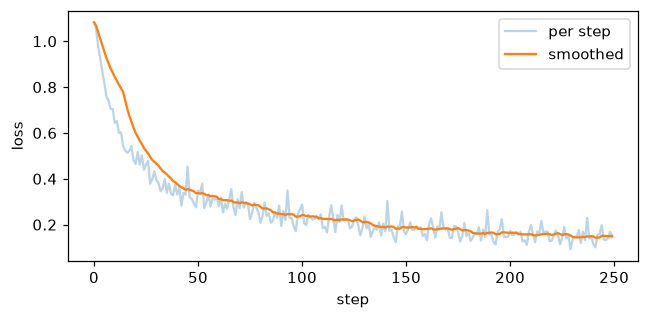

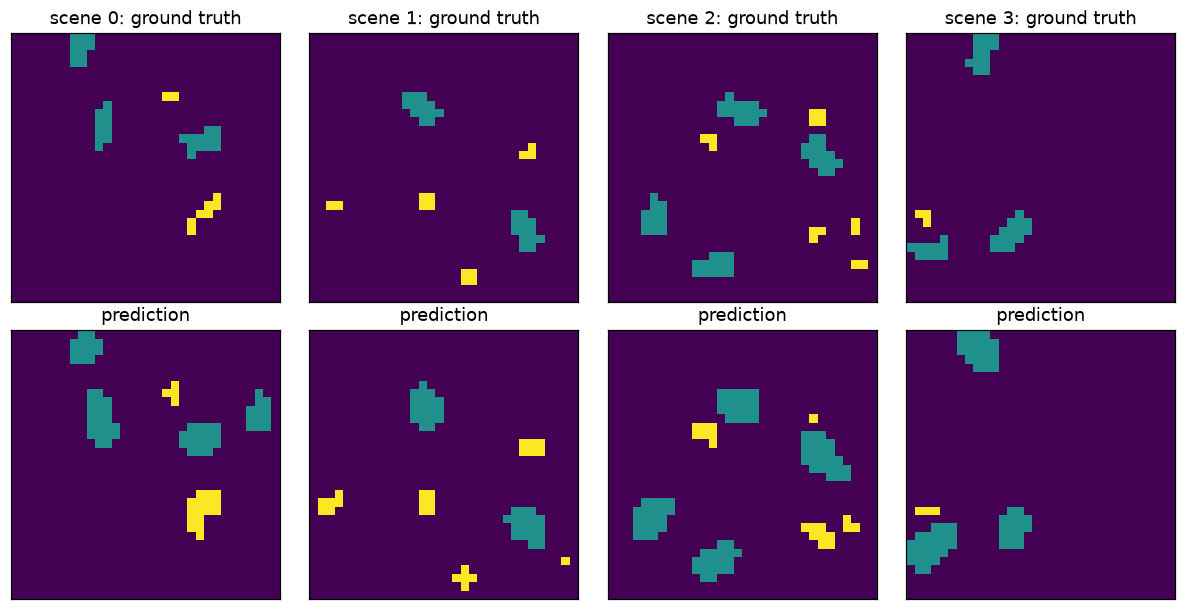

In [15]:
plt.figure(figsize=(6, 3))
plt.plot(trainer.history.losses, alpha=0.3, label="per step"); plt.plot(trainer.history.smoothed(15), label="smoothed")
plt.xlabel("step"); plt.ylabel("loss"); plt.legend(); plt.tight_layout(); plt.show()

tb = test_batches[0]
pred = trainer.predict(tb)
fig, ax = plt.subplots(2, 4, figsize=(11, 5.6))
for s in range(4):
    ax[0, s].imshow(tb.bev_labels[s].T, origin="lower", vmin=0, vmax=2, extent=ext); ax[0, s].set_title(f"scene {s}: ground truth")
    ax[1, s].imshow(pred[s].T, origin="lower", vmin=0, vmax=2, extent=ext); ax[1, s].set_title("prediction")
for a in ax.ravel(): a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

### Does it really use the geometry? 🔬
Keep images and labels fixed, but **rotate the camera extrinsics by 90°**. A lifter that truly maps pixels to the world through
the calibration must now fail. (`lifting-verify` does this for every lifter.)

In [16]:
Rz = torch.eye(4); Rz[0, 0], Rz[0, 1], Rz[1, 0], Rz[1, 1] = 0.0, -1.0, 1.0, 0.0     # 90 degrees about z
rotate_rig = lambda b: dataclasses.replace(b, cameras=b.cameras.transformed(Rz))

good = trainer.evaluate(test_batches).mean_foreground()
bad  = trainer.evaluate(test_batches, transform=rotate_rig).mean_foreground()
print(f"mIoU, correct extrinsics: {good:.3f}")
print(f"mIoU, rotated extrinsics: {bad:.3f}   -> drops by {100 * (1 - bad / max(good, 1e-9)):.0f}%")

mIoU, correct extrinsics: 0.442
mIoU, rotated extrinsics: 0.016   -> drops by 96%


## Step 8: Recap and exercises

```
pixel features ─► depth head ─► p(d), context ─► lifted = p(d) ⊗ context        (B,N,C,D,H,W)
frustum grid   ─► unproject (pixel, depth bin) ─► 3D point ─► voxel index
                                  voxel_pooling: Σ lifted over points in the same voxel ─► voxel volume ─► fold height ─► BEV
```
**Pros:** the original, widely used BEV lifter; sum-pooling naturally accumulates evidence. **Cons:** holes far away; memory of `D·H·W` points per camera;
no occlusion handling (every depth along the ray keeps `p(d)` mass).

### 🧪 Exercises
1. In Step 4, use a finer feature map (`feats[0]` is 12×24; use the full 48×96) and recount the holes.
2. Change `reduce="sum"` to `"mean"` inside `splat` (edit `LiftSplatLifter`) and compare the training curve.
3. Reduce `DepthBins` to 12 bins; how does the number of frustum points change, and what happens to the hole map?
4. Compare the BEV prediction quality and speed with `depth_warp` (pull) at the same depth bins.
5. Plot the frustum points of a camera that is rotated 90° (Step 1) and relate it to the rotated-extrinsics test below.